In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

In [4]:
np.random.seed(42)

n = 500

data = pd.DataFrame({
    'Organization_ID': range(1, n+1),
    'Industry': np.random.choice(['IT','Healthcare','Finance','Education','Retail'], n),
    'Company_Size': np.random.choice(['Small','Medium','Large'], n),
    'Employee_Count': np.random.randint(50,5000,n),
    'AI_Tool': np.random.choice(['ChatGPT','Copilot','Gemini','Claude'], n),
    'Adoption_Year': np.random.randint(2020,2026,n),
    'Productivity_Gain': np.random.randint(10,80,n),
    'Satisfaction_Score': np.random.randint(1,11,n),
    'AI_Investment': np.random.randint(10000,100000,n),
    'Cost_Savings': np.random.randint(5000,80000,n)
})

data.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,Productivity_Gain,Satisfaction_Score,AI_Investment,Cost_Savings
0,1,Education,Medium,2610,Copilot,2025,21,2,66699,35106
1,2,Retail,Small,3441,Claude,2020,41,9,91253,70458
2,3,Finance,Medium,3015,Claude,2023,22,3,56092,21589
3,4,Retail,Small,3693,Gemini,2021,40,2,73671,12214
4,5,Retail,Large,3900,Copilot,2025,29,10,20350,32127


In [5]:
print("Number of Organizations:", data.shape[0])

Number of Organizations: 500


In [6]:
print(data['AI_Tool'].value_counts())

AI_Tool
Claude     134
Copilot    132
Gemini     117
ChatGPT    117
Name: count, dtype: int64


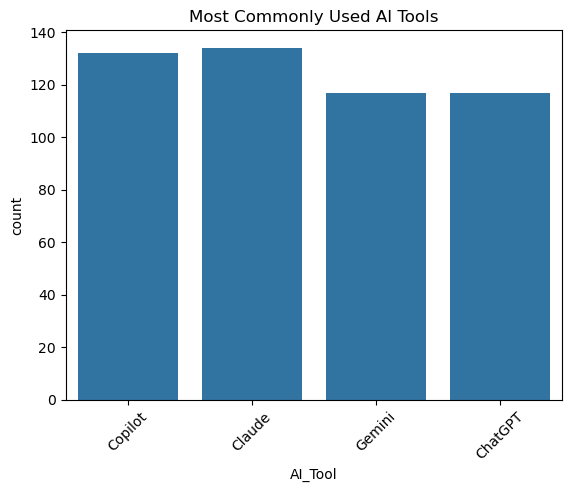

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='AI_Tool', data=data)
plt.title("Most Commonly Used AI Tools")
plt.xticks(rotation=45)
plt.show()

In [9]:
print(data['Industry'].value_counts())

Industry
Education     112
IT            109
Healthcare     95
Retail         93
Finance        91
Name: count, dtype: int64


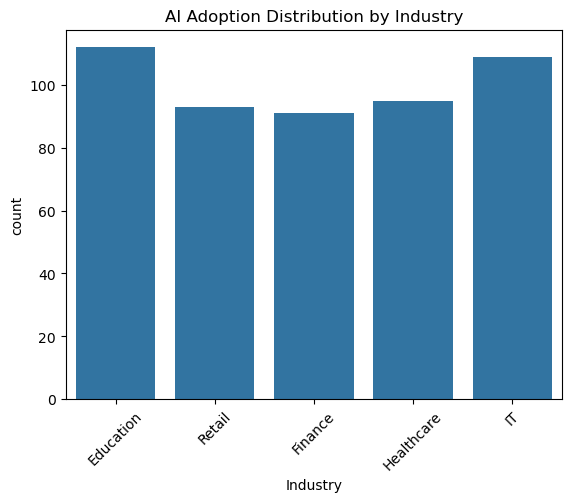

In [10]:
sns.countplot(x='Industry', data=data)
plt.title("AI Adoption Distribution by Industry")
plt.xticks(rotation=45)
plt.show()

In [11]:
print("Average Productivity Gain:", data['Productivity_Gain'].mean())

Average Productivity Gain: 42.864


In [12]:
avg_usage = data.groupby('Industry')['Productivity_Gain'].mean()
print(avg_usage)

Industry
Education     39.116071
Finance       45.142857
Healthcare    42.684211
IT            41.128440
Retail        47.365591
Name: Productivity_Gain, dtype: float64


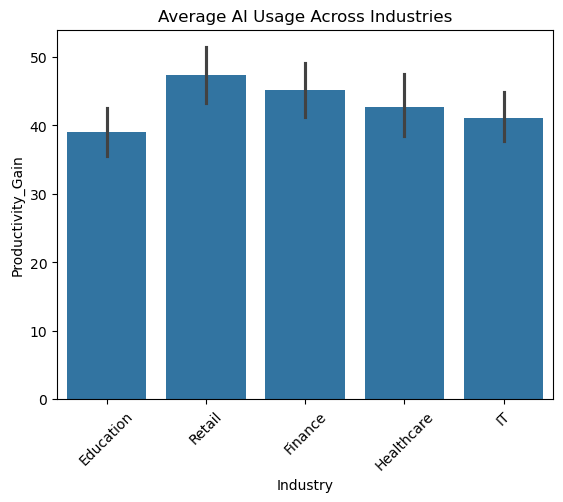

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Industry', y='Productivity_Gain', data=data)
plt.title("Average AI Usage Across Industries")
plt.xticks(rotation=45)
plt.show()

In [14]:
print(data['Company_Size'].value_counts())

Company_Size
Small     175
Medium    166
Large     159
Name: count, dtype: int64


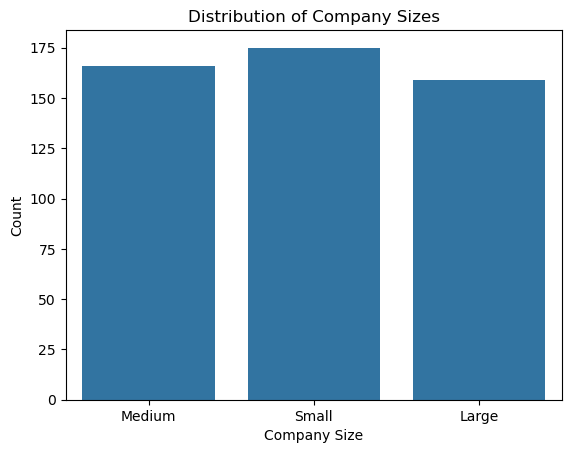

In [15]:
sns.countplot(x='Company_Size', data=data)
plt.title("Distribution of Company Sizes")
plt.xlabel("Company Size")
plt.ylabel("Count")
plt.show()

AI_Tool        ChatGPT  Claude  Copilot  Gemini
Adoption_Year                                  
2020                17      30       21      19
2021                22      25       22      21
2022                11      19       21      15
2023                22      22       19      26
2024                26      20       21      17
2025                19      18       28      19


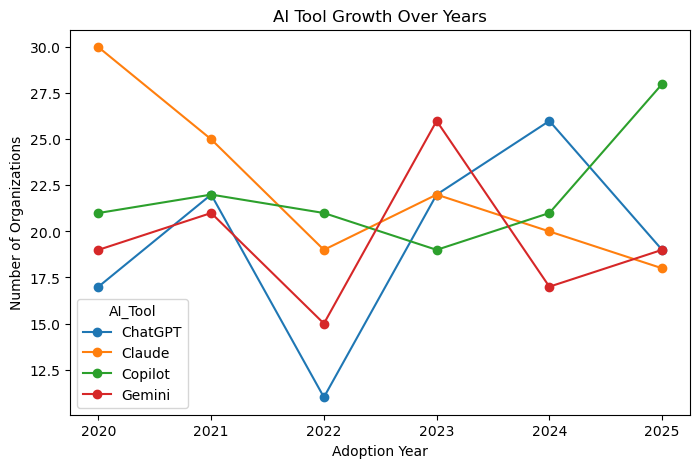

In [16]:
tool_growth = data.groupby(['Adoption_Year', 'AI_Tool']).size().unstack()

print(tool_growth)

tool_growth.plot(figsize=(8,5), marker='o')
plt.title("AI Tool Growth Over Years")
plt.xlabel("Adoption Year")
plt.ylabel("Number of Organizations")
plt.show()

In [17]:
industry_adoption = data['Industry'].value_counts()

print(industry_adoption)

Industry
Education     112
IT            109
Healthcare     95
Retail         93
Finance        91
Name: count, dtype: int64


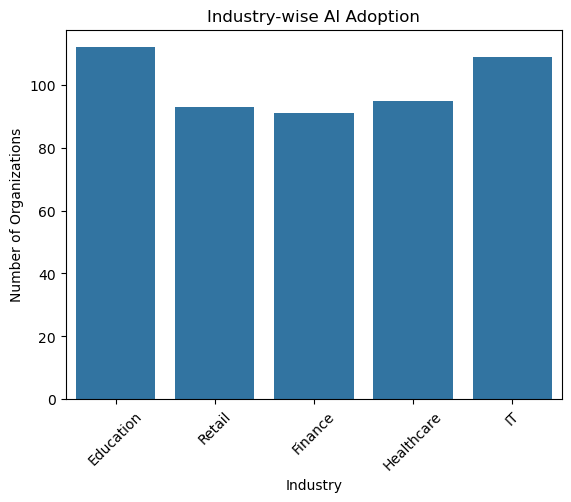

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Industry', data=data)
plt.title("Industry-wise AI Adoption")
plt.xticks(rotation=45)
plt.xlabel("Industry")
plt.ylabel("Number of Organizations")
plt.show()

In [19]:
adoption_productivity = data.groupby('Adoption_Year')['Productivity_Gain'].mean()
print(adoption_productivity)

Adoption_Year
2020    43.034483
2021    43.388889
2022    38.833333
2023    44.494382
2024    45.714286
2025    40.714286
Name: Productivity_Gain, dtype: float64


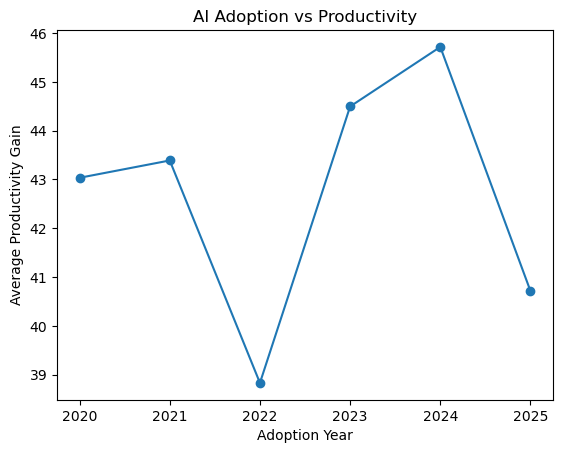

In [20]:
import matplotlib.pyplot as plt

adoption_productivity.plot(marker='o')
plt.title("AI Adoption vs Productivity")
plt.xlabel("Adoption Year")
plt.ylabel("Average Productivity Gain")
plt.show()

In [21]:
company_adoption = data.groupby('Company_Size')['Adoption_Year'].count()
print(company_adoption)

Company_Size
Large     159
Medium    166
Small     175
Name: Adoption_Year, dtype: int64


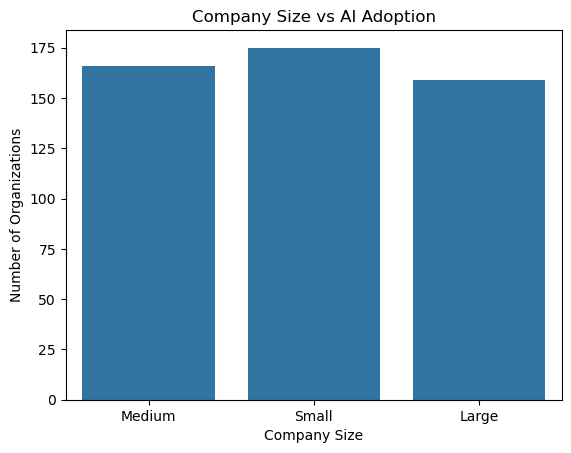

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Company_Size', data=data)
plt.title("Company Size vs AI Adoption")
plt.xlabel("Company Size")
plt.ylabel("Number of Organizations")
plt.show()

In [23]:
from scipy.stats import ttest_ind

# Separate productivity values by company size
small = data[data['Company_Size'] == 'Small']['Productivity_Gain']
large = data[data['Company_Size'] == 'Large']['Productivity_Gain']

# Perform T-Test
t_stat, p_value = ttest_ind(small, large)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject H₀")
    print("Business Interpretation: Company size has a significant impact on AI adoption/productivity.")
else:
    print("Fail to Reject H₀")
    print("Business Interpretation: Company size has no significant impact on AI adoption/productivity.")

T-Statistic: -0.10170437905640975
P-Value: 0.9190527220896787
Fail to Reject H₀
Business Interpretation: Company size has no significant impact on AI adoption/productivity.


Organization_Category
Traditional Organizations    156
Developing Organizations     146
Growth Champions             135
Top Innovators                63
Name: count, dtype: int64
                           Productivity_Gain  Satisfaction_Score  Cost_Savings
Organization_Category                                                         
Developing Organizations           38.390411            5.315068  43339.897260
Growth Champions                   60.177778            5.140741  38841.400000
Top Innovators                     74.666667            5.158730  39226.619048
Traditional Organizations          19.224359            5.250000  39614.141026


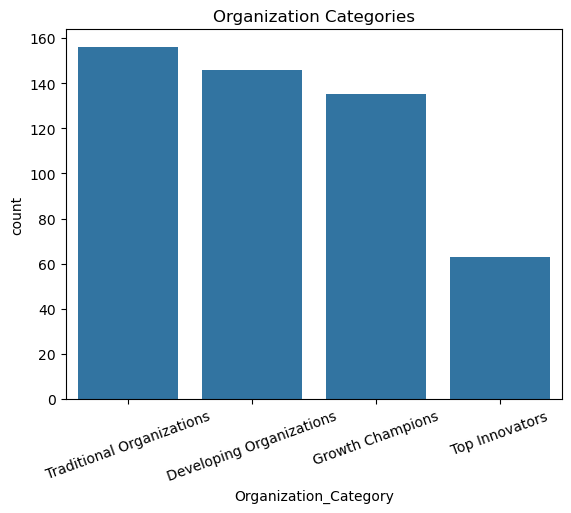

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Custom Organization Categories
def category(row):
    if row['Productivity_Gain'] >= 70:
        return "Top Innovators"
    elif row['Productivity_Gain'] >= 50:
        return "Growth Champions"
    elif row['Productivity_Gain'] >= 30:
        return "Developing Organizations"
    else:
        return "Traditional Organizations"

data['Organization_Category'] = data.apply(category, axis=1)

# Display category counts
print(data['Organization_Category'].value_counts())

# Average values for each category
print(data.groupby('Organization_Category')[['Productivity_Gain',
                                             'Satisfaction_Score',
                                             'Cost_Savings']].mean())

# Visualization
sns.countplot(x='Organization_Category', data=data)
plt.title("Organization Categories")
plt.xticks(rotation=20)
plt.show()

In [28]:
corr = data[['Productivity_Gain','Employee_Count','AI_Investment',
             'Cost_Savings','Satisfaction_Score']].corr()

print(corr['Satisfaction_Score'].sort_values(ascending=False))

Satisfaction_Score    1.000000
Employee_Count       -0.009902
Productivity_Gain    -0.020544
AI_Investment        -0.064966
Cost_Savings         -0.072371
Name: Satisfaction_Score, dtype: float64


AI_Tool
ChatGPT    5.282051
Claude     5.149254
Copilot    5.227273
Gemini     5.264957
Name: Satisfaction_Score, dtype: float64


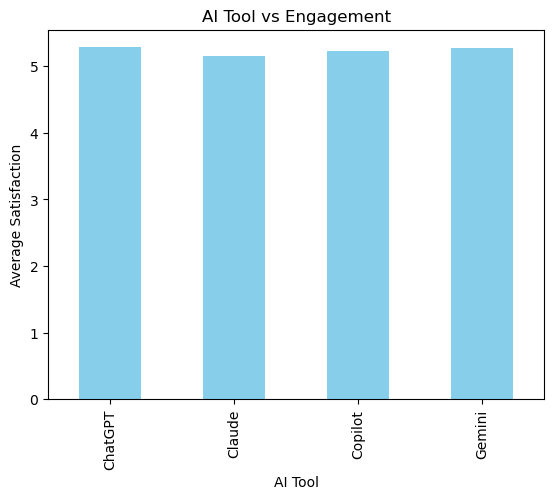

In [29]:
engagement = data.groupby('AI_Tool')['Satisfaction_Score'].mean()
print(engagement)

engagement.plot(kind='bar', color='skyblue')
plt.title("AI Tool vs Engagement")
plt.xlabel("AI Tool")
plt.ylabel("Average Satisfaction")
plt.show()

In [30]:
low_attention = data[data['Satisfaction_Score'] < 5]

print(low_attention.groupby('Company_Size').size())
print(low_attention.groupby('Industry').size())

Company_Size
Large     66
Medium    76
Small     77
dtype: int64
Industry
Education     55
Finance       34
Healthcare    38
IT            53
Retail        39
dtype: int64


In [31]:
recommendation = data.groupby('AI_Tool')['Satisfaction_Score'].mean().sort_values(ascending=False)

print("Recommended AI Tools:")
print(recommendation)

Recommended AI Tools:
AI_Tool
ChatGPT    5.282051
Gemini     5.264957
Copilot    5.227273
Claude     5.149254
Name: Satisfaction_Score, dtype: float64
